In [1]:
import astropy.coordinates as coord
import astropy.units as u
import numpy as np
import gala.coordinates as gc
import gala.dynamics as gd
import gala.potential as gp
from gala.units import galactic

import numpy as np
import matplotlib.pyplot as plt 

sim_data_carthesian: [[ -12.15998237   -0.86628667   -2.13184046  203.50306682 -223.21115337
   145.14736613]
 [  -1.62008356   -8.3450776     3.45005961  306.62454676 -144.15301528
   117.26778235]
 [ -11.38773888   -1.66143059   -1.64236808  212.57225892 -222.23283492
   148.55493982]
 ...
 [  -7.42642772   -4.87127932    0.77093235  264.9478289  -205.46305125
   152.33298103]
 [  -7.61857801   -4.97299009    0.79669405  266.04352916 -206.90942626
   151.20633047]
 [  -7.41415743   -4.85147397    0.75596883  264.49784528 -204.79376309
   149.6264992 ]]
sim_data_projected: [[ 6.89358079e+01  3.91122901e+00  4.65723418e+00  1.55335214e+01
  -1.67859517e+01 -1.41550665e+02]
 [ 1.99476916e+02 -4.45663354e+01  1.11209133e+01 -5.12466075e-02
  -8.89671614e-01  4.97957827e+02]
 [ 7.83447317e+01 -6.06602404e+00  4.02389166e+00  1.87881477e+01
  -2.02618384e+01 -2.70741335e+01]
 ...
 [ 1.55491794e+02 -4.68509888e+01  4.97753397e+00  8.22445827e+00
  -1.78766823e+00  4.98439340e+02]
 [ 1.52847

Text(0, 0.5, 'y [kpc]')

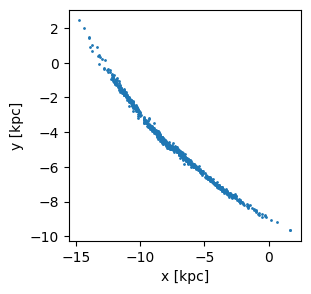

In [2]:
i = 0
# i = 119
data = np.load(f'../project_stream/data/streams/data_gala/simulation_{i}.npz')
sim_data = data['sim_data_carthesian']

for k in data.keys():
    print(f"{k}: {data[k]}")

fig = plt.figure(figsize=(3, 3))
plt.scatter(sim_data[:, 0], sim_data[:, 1], s=1)
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')


j = 1 is NGC3201 !


Text(0, 0.5, '$z$ [kpc]')

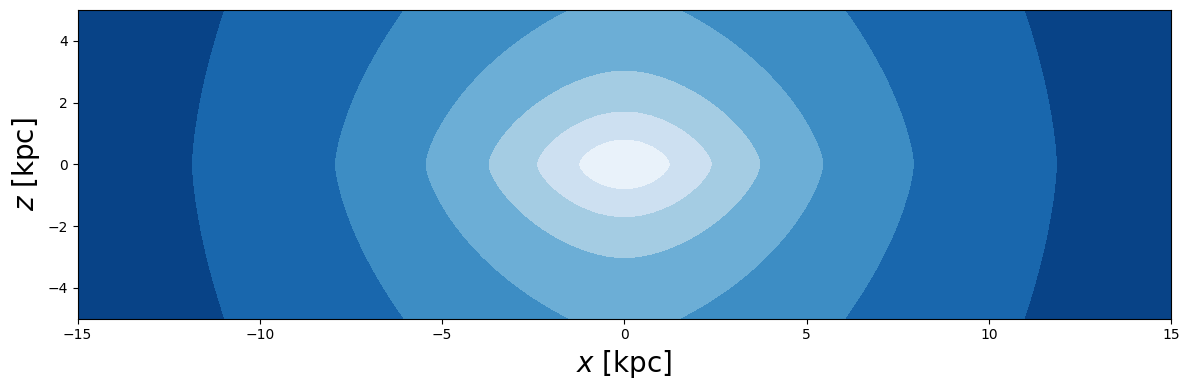

In [6]:
print('j =',data['j'][0], 'is NGC3201 !')

pot = gp.CCompositePotential()

pot['halo'] = gp.NFWPotential(m     = data['m_Triaxial_halo'][0],
                              r_s   = data['r_Triaxial_halo'][0],
                              a     = 1,
                              b     = data['q1_Triaxial_halo'][0],
                              # c     = data['q2_Triaxial_halo'][0],
                              c = 20,
                              units =galactic)

pot['thin_disk'] = gp.MN3ExponentialDiskPotential(m = 4 * np.pi * data['rho_thin_disk'][0]*data['hr_thin_disk'][0]**2 * data['hz_thin_disk'][0],
                                                h_R=data['hr_thin_disk'][0],
                                                h_z=data['hz_thin_disk'][0],
                                                units=galactic,
                                                positive_density=True)
pot['thick_disk'] = gp.MN3ExponentialDiskPotential(m = 4 * np.pi * data['rho_thick_disk'][0] *data['hr_thick_disk'][0]**2 * data['hz_thick_disk'][0],
                                                 h_R=data['hr_thick_disk'][0],
                                                 h_z=data['hz_thick_disk'][0],
                                                 units=galactic,
                                                 positive_density=True)
pot['bulge'] = gp.PowerLawCutoffPotential(m=data['m_bulge'][0],
                                          r_c=data['r_bulge'][0],
                                          alpha=data['alpha_bulge'][0],
                                          units=galactic)

w0 = coord.Galactocentric(x=data['x'][0]*u.kpc, y=data['y'][0]*u.kpc, z=data['z'][0]*u.kpc,
                          v_x=data['vx'][0]*u.km/u.s, v_y=data['vy'][0]*u.km/u.s, v_z=data['vz'][0]*u.km/u.s)
w0 = gd.PhaseSpacePosition(w0)

prog_mass = data['m_progenitor'][0] * u.Msun
b_prog = data['a_progenitor'][0] * u.pc
NGC3201_pot = gp.PlummerPotential(m=prog_mass, b=b_prog, units=galactic)

fig, ax = plt.subplots(1, 1, figsize=(12, 4), layout='tight')
x = np.linspace(-15, 15, 100)
z = np.linspace(-5, 5, 100)
pot.plot_contours(grid=(x, 1.0, z), ax=ax)
ax.set_xlabel('$x$ [kpc]', fontsize=20)
ax.set_ylabel('$z$ [kpc]', fontsize=20)

In [10]:
from gala.dynamics import mockstream as ms
df = gd.ChenStreamDF()

gen_NGC3201 = ms.MockStreamGenerator(df, pot,
                                  progenitor_potential=NGC3201_pot)
NGC3201_stream, _ = gen_NGC3201.run(w0, prog_mass,
                                    dt=-1.5*u.Myr, n_steps=1000, release_every=2) 

        Use name instead. [gala.dynamics.core]


In [11]:
NGC3201_stream.vel._d_x.to(u.km/u.s).value.shape

(1002,)

        Use name instead. [gala.dynamics.core]


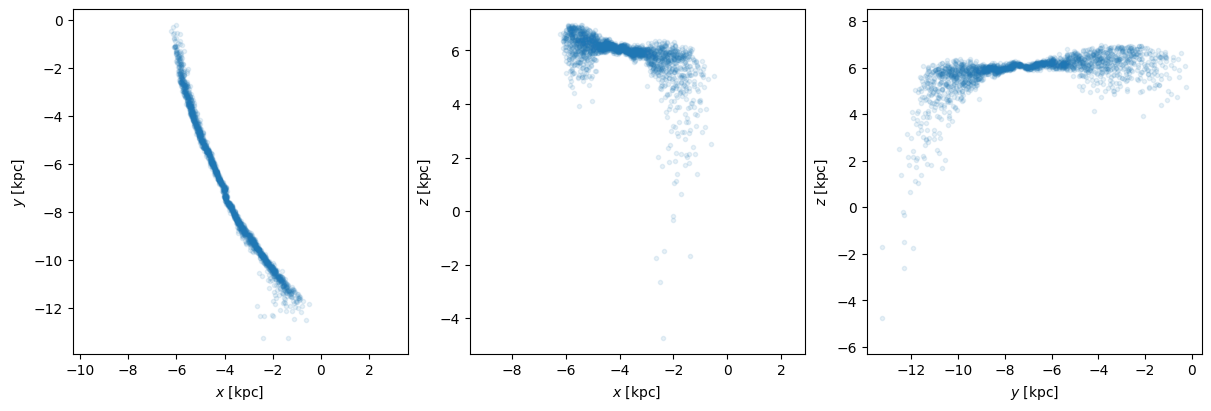

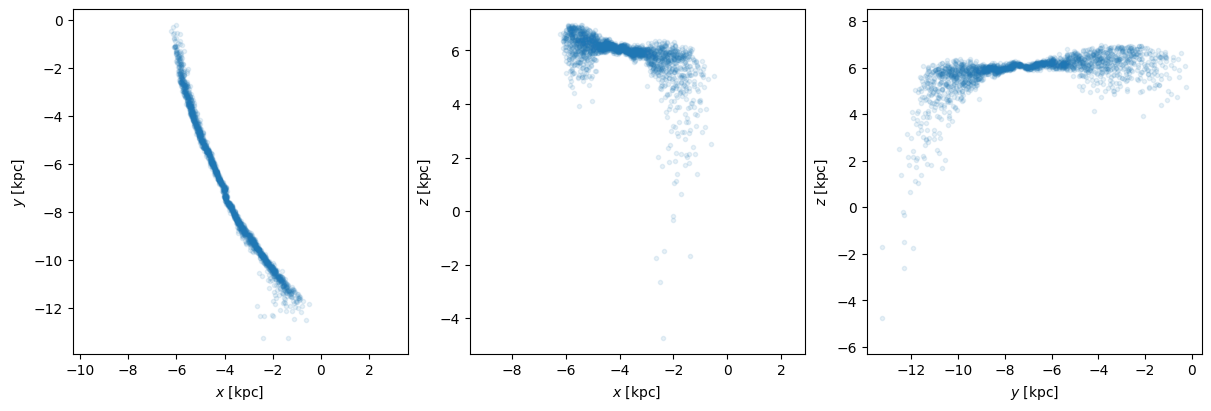

In [9]:
NGC3201_stream.plot(alpha=0.1)


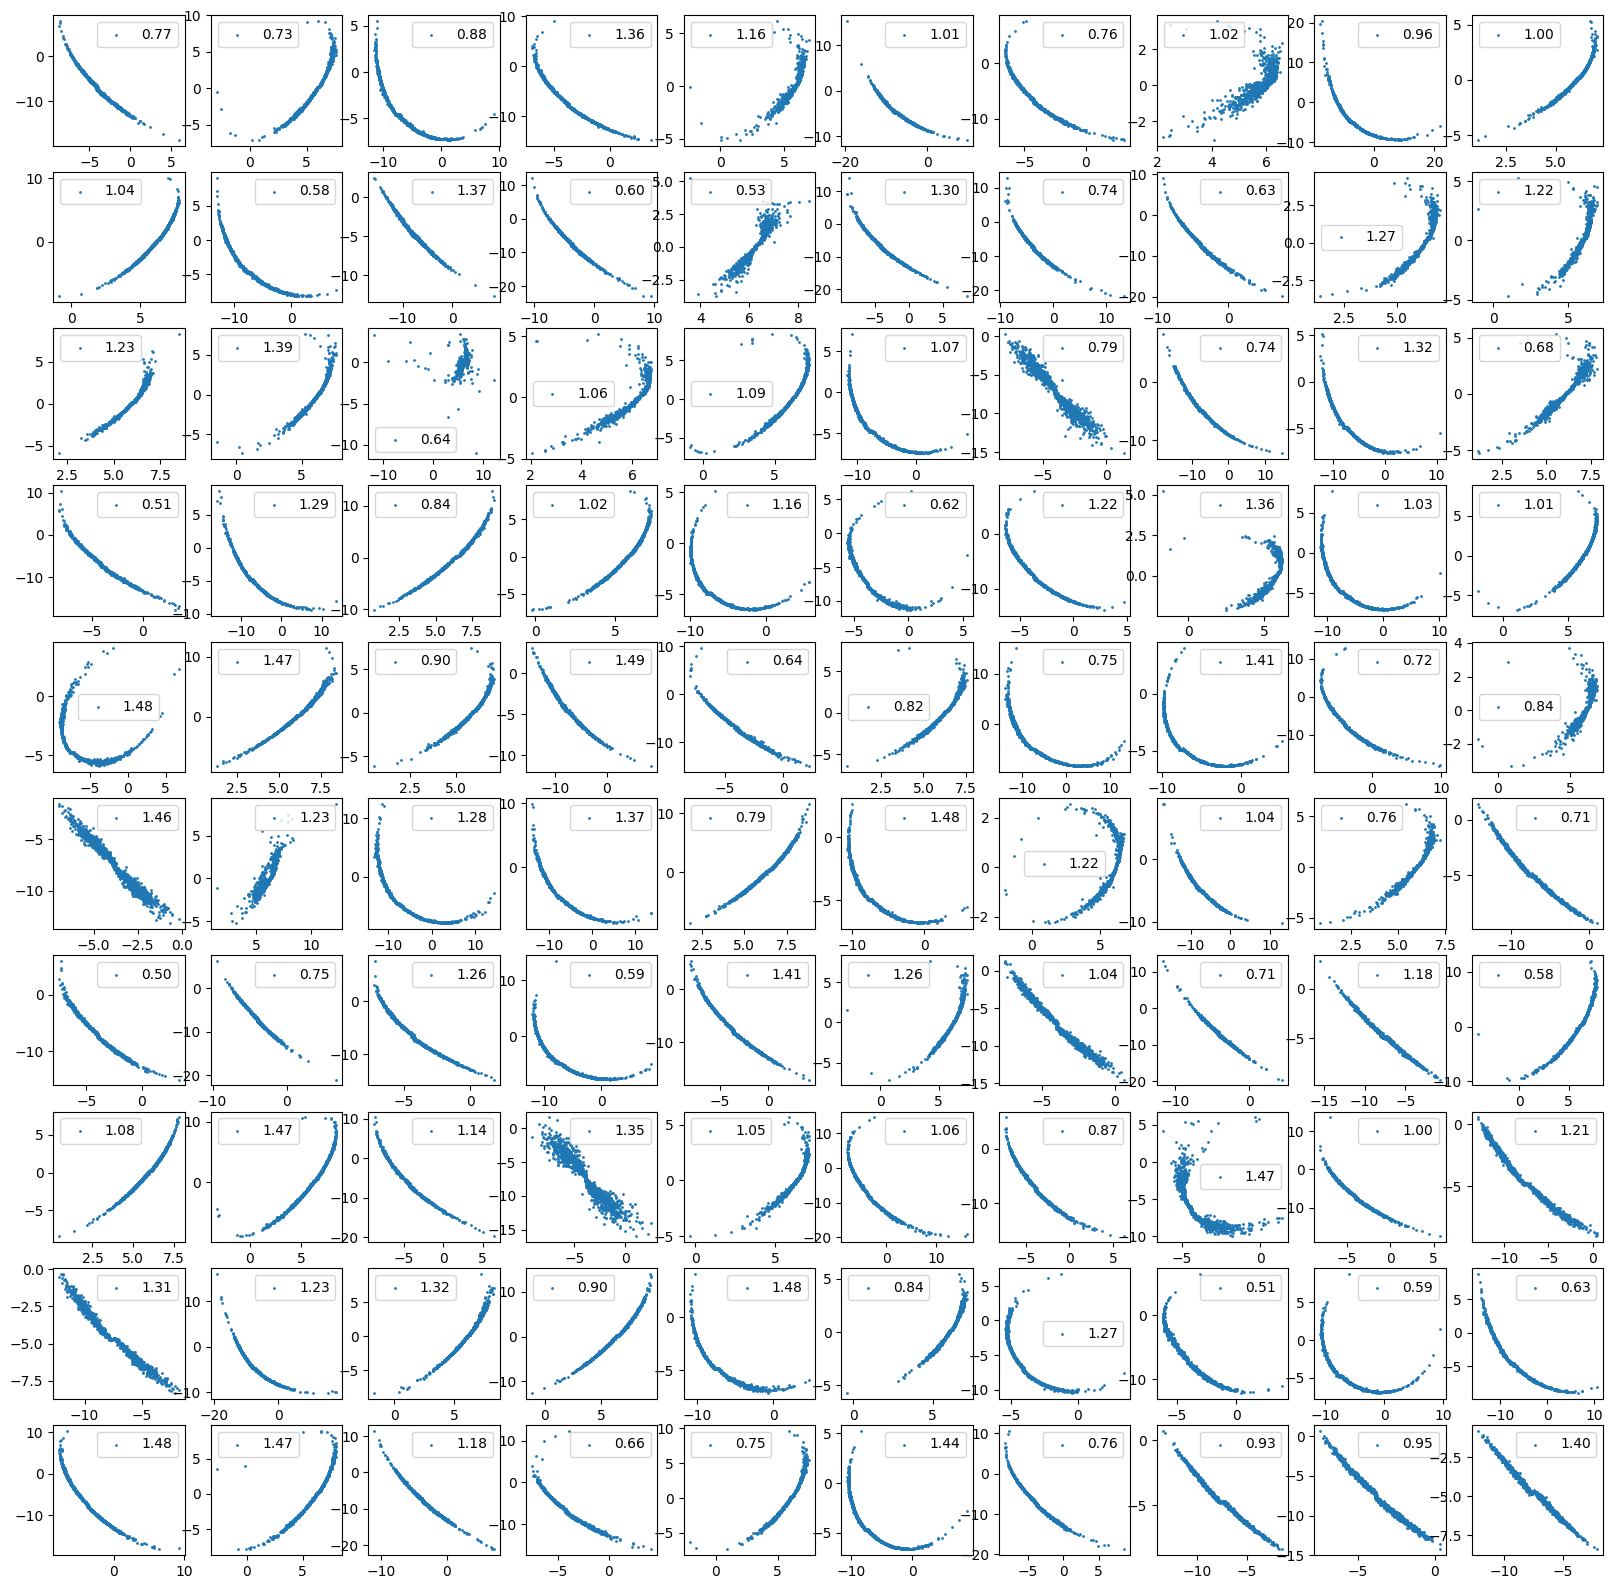

In [4]:
fig = plt.figure(figsize=(20, 20))
for idx, i in enumerate(range(100, 200)):
    data = np.load(f'../project_stream/data/streams/data_gala/simulation_{i}.npz')
    sim_data = data['sim_data_carthesian']

    ax = fig.add_subplot(10, 10, idx+1)
    ax.scatter(sim_data[:, 0], sim_data[:, 1], s=1, label=f"{data['q2_Triaxial_halo'][0]:.2f}")
    ax.legend()